In [4]:
import os
import pandas as pd
from dataset import load_dataset
import joblib
from regression.RandomForest.random_forest_regression import RandomForestRegressorModel
from regression.probabilistic_rf_scoring import fit_rank_pdfs_loglik
from regression.probabilistic_rf_scoring import plot_ranked_pdfs
from regression.probabilistic_rf_scoring import plot_pdf_with_true_target
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("default")
from plot_style import set_plot_style
set_plot_style()

In [5]:
TARGET_COL = "trq_target"
FEATURES=["trq_measured","mgt","ias","oat","np_ng_ratio","pa"]
TRAIN_PATH_SPLIT= "../../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT= "../../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH= "../../../../output/random_forest_regressor/model_target/"
MODEL_PATH="random_forest_model_target.pkl"
METRIC_TRAIN="metric_train.csv"
METRIC_TEST="metric_test.csv"

In [6]:
train_df = load_dataset(TRAIN_PATH_SPLIT)
test_df = load_dataset(TEST_PATH_SPLIT)

X_train = train_df[FEATURES].values
y_train = train_df[TARGET_COL].values

X_test = test_df[FEATURES].values
y_test = test_df[TARGET_COL].values

In [15]:
rf_model = RandomForestRegressorModel(
    n_estimators=500,
    min_samples_leaf=3,
)

if os.path.exists(OUTPUT_PATH+MODEL_PATH):
    rf_model=joblib.load(OUTPUT_PATH+MODEL_PATH)
else:
    rf_model.fit(X_train, y_train)
    joblib.dump(rf_model, OUTPUT_PATH + MODEL_PATH)

In [16]:
metric_train=rf_model.evaluate(X_train, y_train,"train")
df_metric_train = pd.DataFrame([metric_train])
df_metric_train.to_csv(OUTPUT_PATH+METRIC_TRAIN, index=False)

metric_validate=rf_model.evaluate(X_test, y_test,"test")
df_metric_test = pd.DataFrame([metric_validate])
df_metric_test.to_csv(OUTPUT_PATH+METRIC_TEST, index=False)


Metrics on train
MAE  : 0.077253
RMSE : 0.139105
R²   : 0.999903

Metrics on test
MAE  : 0.126155
RMSE : 0.218526
R²   : 0.999764


In [27]:
id=38
test_row=test_df.iloc[id]
torque_measured=test_row['trq_measured']
torque_margin_true=test_row['trq_margin']
testX = test_df.loc[[id], FEATURES].to_numpy()
tree_preds = rf_model.predict_trees(testX)
tree_preds["trq_margin_pred"] = (torque_measured / tree_preds["trq_target_prediction"] - 1) * 100
tree_preds.head()

,trq_target_prediction,trq_margin_pred
0,54.115825,15.677808
1,54.023408,15.875696
2,54.123469,15.661470
3,53.910446,16.118498
4,54.091606,15.729601


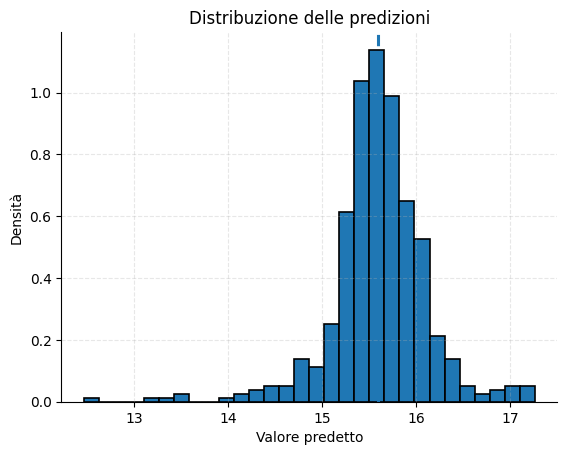

In [28]:
plt.figure()
plt.hist(tree_preds["trq_margin_pred"], bins=30, density=True)
plt.axvline(np.median(tree_preds["trq_margin_pred"]), linestyle="--", label="Predizione puntuale")
plt.xlabel("Valore predetto")
plt.xlabel("Valore predetto")
plt.ylabel("Densità")
plt.title("Distribuzione delle predizioni")
plt.show()

In [29]:
ranking,best =  fit_rank_pdfs_loglik(tree_preds["trq_margin_pred"])


=== CLASSIFICA (LOG-LIKELIHOOD) ===
01) t            | loglik=-310.68
02) laplace      | loglik=-317.42
03) logistic     | loglik=-328.83
04) cauchy       | loglik=-348.33
05) beta         | loglik=-368.41
06) norm         | loglik=-375.16
07) lognorm      | loglik=-375.16
08) nakagami     | loglik=-375.29
09) f            | loglik=-376.15
10) erlang       | loglik=-384.63
11) gamma        | loglik=-384.83
12) weibull_min  | loglik=-387.40
13) chi2         | loglik=-388.19
14) betaprime    | loglik=-524.53
15) gumbel_r     | loglik=-538.56
16) powerlaw     | loglik=-658.30
17) rayleigh     | loglik=-751.47
18) uniform      | loglik=-783.70
19) expon        | loglik=-1071.34
20) pareto       | loglik=-1071.34


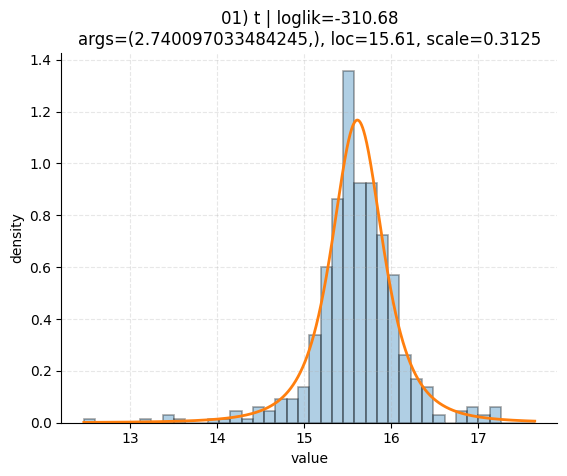

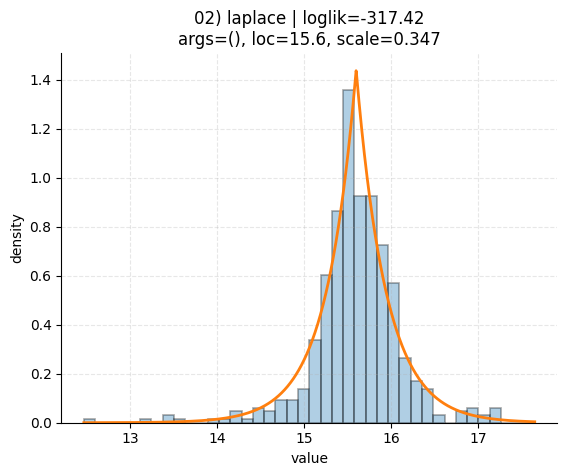

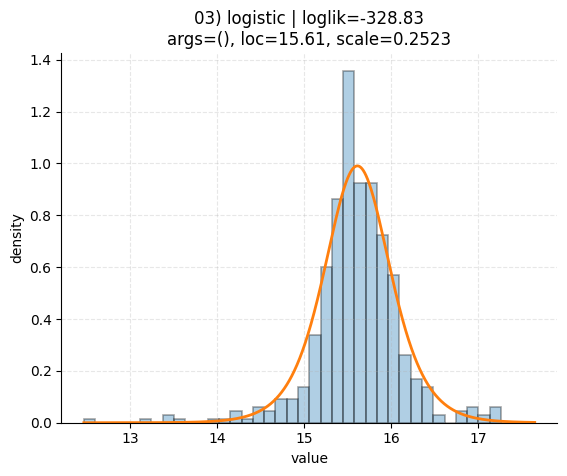

In [30]:
plot_ranked_pdfs(ranking,tree_preds["trq_margin_pred"])

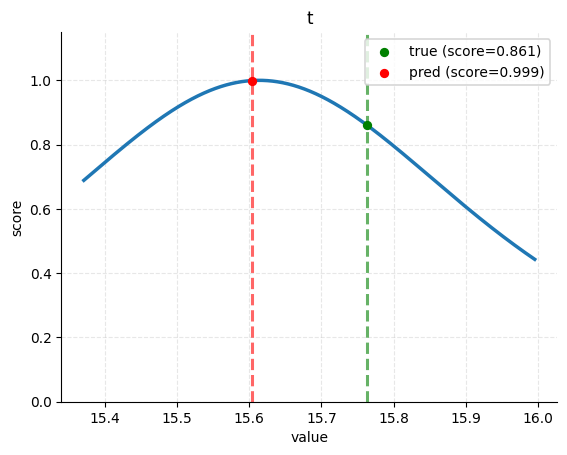

{'pdf_type': 't',
 'true_target': 15.762909337379154,
 'prediction': 15.603558481786811,
 'score_true': 0.8611430328231223,
 'score_pred': 0.9992844015037352,
 'x_range': (15.370766343526851, 15.995701475639114)}

In [31]:
plot_pdf_with_true_target(best["pdf_type"],best["pdf_args"],torque_margin_true,np.mean(tree_preds["trq_margin_pred"]))

In [17]:
r = permutation_importance(
    rf_model.model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.Series(r.importances_mean, index=FEATURES)\
             .sort_values(ascending=False)

print(perm_imp.head(10))

/Users/alessandropettinaro/PycharmProjects/PHM_2024_Project/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


mgt             0.507832
oat             0.301525
trq_measured    0.161045
np_ng_ratio     0.033680
pa              0.006045
ias             0.004013
dtype: float64


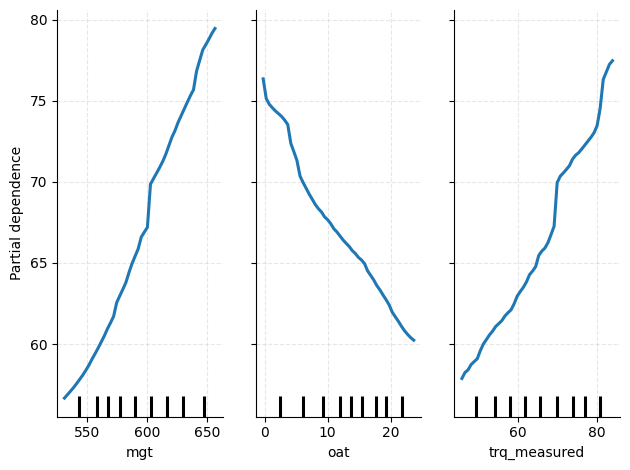

In [18]:
X_test_df = pd.DataFrame(X_test, columns=FEATURES)
top_main = ["mgt", "oat", "trq_measured"]

PartialDependenceDisplay.from_estimator(
    rf_model.model if hasattr(rf_model, "model") else rf_model,
    X_test_df,
    features=top_main,
    grid_resolution=50
)

plt.tight_layout()
plt.show()

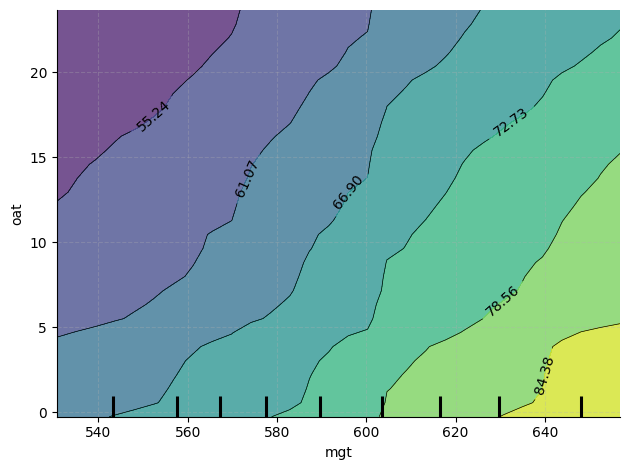

In [19]:
PartialDependenceDisplay.from_estimator(
    rf_model.model if hasattr(rf_model, "model") else rf_model,
    X_test_df,
    features=[("mgt", "oat")],
    grid_resolution=30
)

plt.tight_layout()
plt.show()

In [ ]:
import shap

X_test_df = pd.DataFrame(X_test, columns=FEATURES)


model = rf_model.model if hasattr(rf_model, "model") else rf_model

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)
shap.summary_plot(shap_values, X_test_df)